In [206]:
import pandas as pd
import numpy as np
from mlxtend.plotting import plot_decision_regions  

In [207]:
df=pd.DataFrame()

In [208]:
df['X1']=[1,4,5,7,8,2,3,5,6,7,8]
df['X2']=[5,3,6,8,9,3,6,9,4,7,8]
df['label']=[1,1,1,1,1,0,0,0,0,0,0]

In [209]:
df

,X1,X2,label
0,1,5,1
1,4,3,1
2,5,6,1
3,7,8,1
4,8,9,1
5,2,3,0
6,3,6,0
7,5,9,0
8,6,4,0
9,7,7,0


<Axes: xlabel='X1', ylabel='X2'>

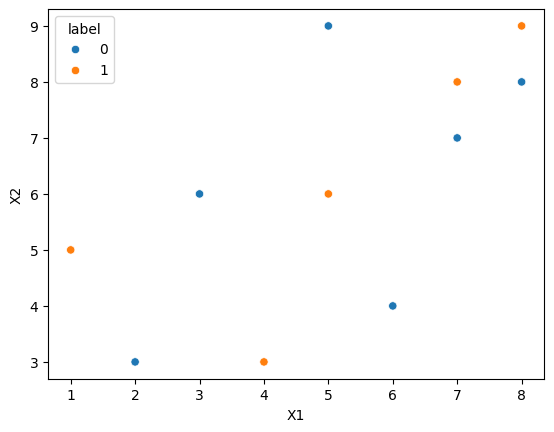

In [210]:
import seaborn as sns
sns.scatterplot(data=df,x='X1',y='X2',hue='label')

In [211]:
df['weights']=1/len(df)

In [212]:
df

,X1,X2,label,weights
0,1,5,1,0.090909
1,4,3,1,0.090909
2,5,6,1,0.090909
3,7,8,1,0.090909
4,8,9,1,0.090909
5,2,3,0,0.090909
6,3,6,0,0.090909
7,5,9,0,0.090909
8,6,4,0,0.090909
9,7,7,0,0.090909


In [213]:
from sklearn.tree import DecisionTreeClassifier
dt1=DecisionTreeClassifier(max_depth=1)
X=df[['X1','X2']].values
y=df['label'].values

In [214]:
dt1.fit(X,y,sample_weight=df['weights'].values)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

[Text(0.5, 0.75, 'X1 <= 1.5\ngini = 0.496\nsamples = 11\nvalue = [0.545, 0.455]\nclass = 0'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [0.0, 0.091]\nclass = 1'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.48\nsamples = 10\nvalue = [0.545, 0.364]\nclass = 0'),
 Text(0.625, 0.5, '  False')]

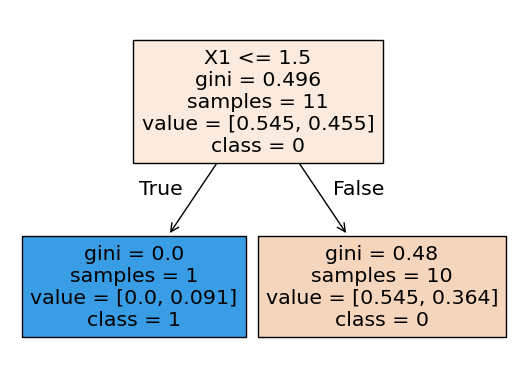

In [215]:
from sklearn.tree import plot_tree
plot_tree(dt1,filled=True,feature_names=['X1','X2'],class_names=['0','1'])

<Axes: >

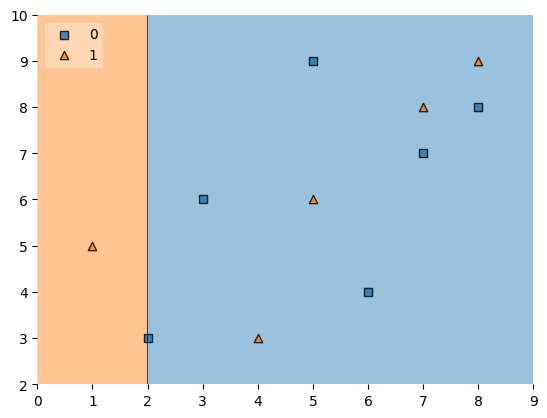

In [216]:
plot_decision_regions(X,y,clf=dt1,legend=2)

In [217]:
df['y_pred']=dt1.predict(X)

In [218]:
df

,X1,X2,label,weights,y_pred
0,1,5,1,0.090909,1
1,4,3,1,0.090909,0
2,5,6,1,0.090909,0
3,7,8,1,0.090909,0
4,8,9,1,0.090909,0
5,2,3,0,0.090909,0
6,3,6,0,0.090909,0
7,5,9,0,0.090909,0
8,6,4,0,0.090909,0
9,7,7,0,0.090909,0


In [219]:
def calculate_model_weight(error):
    return 0.5 * np.log((1-error)/error)

In [220]:
alpha1=calculate_model_weight(0.2)
alpha1

np.float64(0.6931471805599453)

In [221]:
def update_weights(df,alpha):
    if df['label'] == df['y_pred']:
        return df['weights'] * np.exp(-alpha)
    else:
        return df['weights'] * np.exp(alpha)

In [222]:
df['update_weights']=df.apply(update_weights,alpha=alpha1,axis=1)

In [223]:
df

,X1,X2,label,weights,y_pred,update_weights
0,1,5,1,0.090909,1,0.045455
1,4,3,1,0.090909,0,0.181818
2,5,6,1,0.090909,0,0.181818
3,7,8,1,0.090909,0,0.181818
4,8,9,1,0.090909,0,0.181818
5,2,3,0,0.090909,0,0.045455
6,3,6,0,0.090909,0,0.045455
7,5,9,0,0.090909,0,0.045455
8,6,4,0,0.090909,0,0.045455
9,7,7,0,0.090909,0,0.045455


In [224]:
df['update_weights'].sum()

np.float64(1.0454545454545454)

In [225]:
df['normalized_weights']=df['update_weights']/df['update_weights'].sum()

In [226]:
df

,X1,X2,label,weights,y_pred,update_weights,normalized_weights
0,1,5,1,0.090909,1,0.045455,0.043478
1,4,3,1,0.090909,0,0.181818,0.173913
2,5,6,1,0.090909,0,0.181818,0.173913
3,7,8,1,0.090909,0,0.181818,0.173913
4,8,9,1,0.090909,0,0.181818,0.173913
5,2,3,0,0.090909,0,0.045455,0.043478
6,3,6,0,0.090909,0,0.045455,0.043478
7,5,9,0,0.090909,0,0.045455,0.043478
8,6,4,0,0.090909,0,0.045455,0.043478
9,7,7,0,0.090909,0,0.045455,0.043478


In [227]:
df['cumsum_upper']=np.cumsum(df['normalized_weights'])
df['cumsum_lower']=df['cumsum_upper']-df['normalized_weights']

In [228]:
df[['X1','X2','label','weights','y_pred','update_weights','normalized_weights','cumsum_lower','cumsum_upper']]

,X1,X2,label,weights,y_pred,update_weights,normalized_weights,cumsum_lower,cumsum_upper
0,1,5,1,0.090909,1,0.045455,0.043478,0.000000,0.043478
1,4,3,1,0.090909,0,0.181818,0.173913,0.043478,0.217391
2,5,6,1,0.090909,0,0.181818,0.173913,0.217391,0.391304
3,7,8,1,0.090909,0,0.181818,0.173913,0.391304,0.565217
4,8,9,1,0.090909,0,0.181818,0.173913,0.565217,0.739130
5,2,3,0,0.090909,0,0.045455,0.043478,0.739130,0.782609
6,3,6,0,0.090909,0,0.045455,0.043478,0.782609,0.826087
7,5,9,0,0.090909,0,0.045455,0.043478,0.826087,0.869565
8,6,4,0,0.090909,0,0.045455,0.043478,0.869565,0.913043
9,7,7,0,0.090909,0,0.045455,0.043478,0.913043,0.956522


In [229]:
def create_new_dataset(df):
    indices=[] 
    for i in range(df.shape[0]):
        rand=np.random.rand()
        for j in range(df.shape[0]):
            if rand>=df['cumsum_lower'][j] and rand<=df['cumsum_upper'][j]:
                indices.append(j)
                
    return indices

In [230]:
index_values=create_new_dataset(df)
index_values

[2, 2, 1, 7, 4, 3, 9, 4, 7, 1, 2]

In [231]:
second_df=df.iloc[index_values,[0,1,2,3]]

In [232]:
dt2=DecisionTreeClassifier(max_depth=1)
X1=second_df.iloc[:,0:2].values
y1=second_df.iloc[:,2].values
dt2.fit(X1,y1)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

<Axes: >

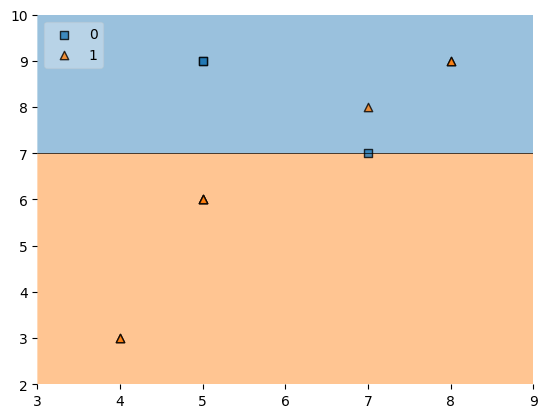

In [233]:
plot_decision_regions(X1,y1,clf=dt2,legend=2)